# Developing a regression model that can predict the price of a car based on its feature.

## Importing the dependencies.

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv(r"C:\Users\rosha\OneDrive\Desktop\car_price_prediction\car_details.csv")

df.head()  # To preview the first few rows


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


# Exploratory Data Analysis (EDA)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [100]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [101]:
df.duplicated().sum()

763

In [102]:
df.nunique()

name             1491
year               27
selling_price     445
km_driven         770
fuel                5
seller_type         3
transmission        2
owner               5
dtype: int64

In [103]:
df=df.drop_duplicates()

In [104]:
df.duplicated().sum()

0

In [105]:
df.shape

(3577, 8)

In [106]:
if 'transmission' in df.columns:   #removing 'transmission' column;
    df = df.drop(columns=['transmission']) #if needed change transmission to required column name
    print("Dropped column 'transmission'")

Dropped column 'transmission'


In [107]:
df['transmission'] = 'manual'      #adding back transmission data
print("Added 'transmission' column with value 'manual' for all rows")

Added 'transmission' column with value 'manual' for all rows


In [108]:
df.nunique()

name             1491
year               27
selling_price     445
km_driven         770
fuel                5
seller_type         3
owner               5
transmission        1
dtype: int64

## convert categorical value into numeric value

In [109]:
from sklearn.preprocessing import LabelEncoder
label_encoder1 = LabelEncoder()
label_encoder2 = LabelEncoder() 
label_encoder3 = LabelEncoder() 
label_encoder4 = LabelEncoder() 
label_encoder5 = LabelEncoder() 

df['name'] = label_encoder1.fit_transform(df['name']) 
df['fuel'] = label_encoder2.fit_transform(df['fuel']) 
df['seller_type'] = label_encoder3.fit_transform(df['seller_type']) 
df['owner'] = label_encoder4.fit_transform(df['owner']) 
df['transmission'] = label_encoder5.fit_transform(df['transmission']) 
df

,name,year,selling_price,km_driven,fuel,seller_type,owner,transmission
0,775,2007,60000,70000,4,1,0,0
1,1041,2007,135000,50000,4,1,0,0
2,505,2012,600000,100000,1,1,0,0
3,118,2017,250000,46000,4,1,0,0
4,279,2014,450000,141000,1,1,2,0
...,...,...,...,...,...,...,...,...
4335,602,2014,409999,80000,1,1,2,0
4336,601,2014,409999,80000,1,1,2,0
4337,777,2009,110000,83000,4,1,2,0
4338,381,2016,865000,90000,1,1,0,0


In [110]:
df['km_driven'].values

array([ 70000,  50000, 100000, ...,  83000,  90000,  40000], dtype=int64)

<Axes: >

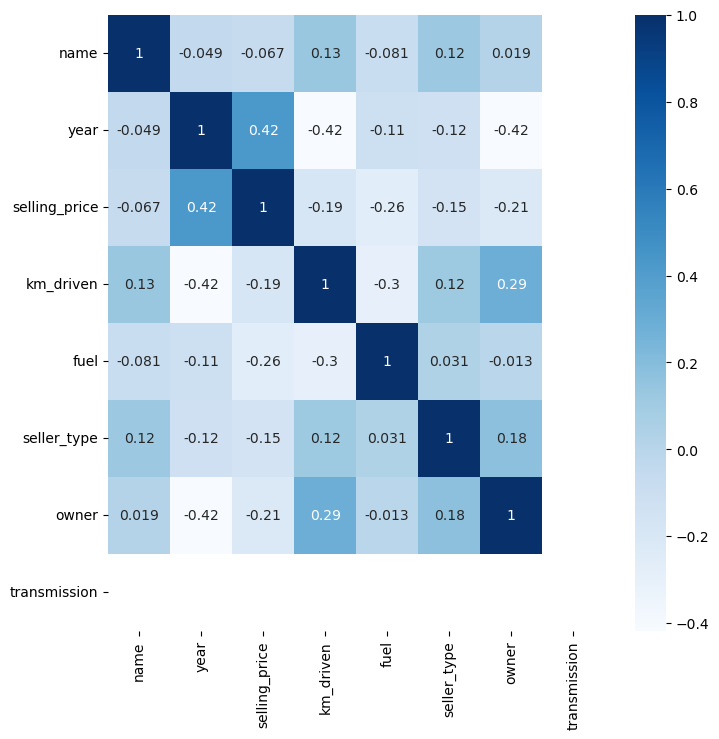

In [111]:
plt.figure(figsize=(8,8))
sns.heatmap(df.corr(),annot=True,cmap='Blues')

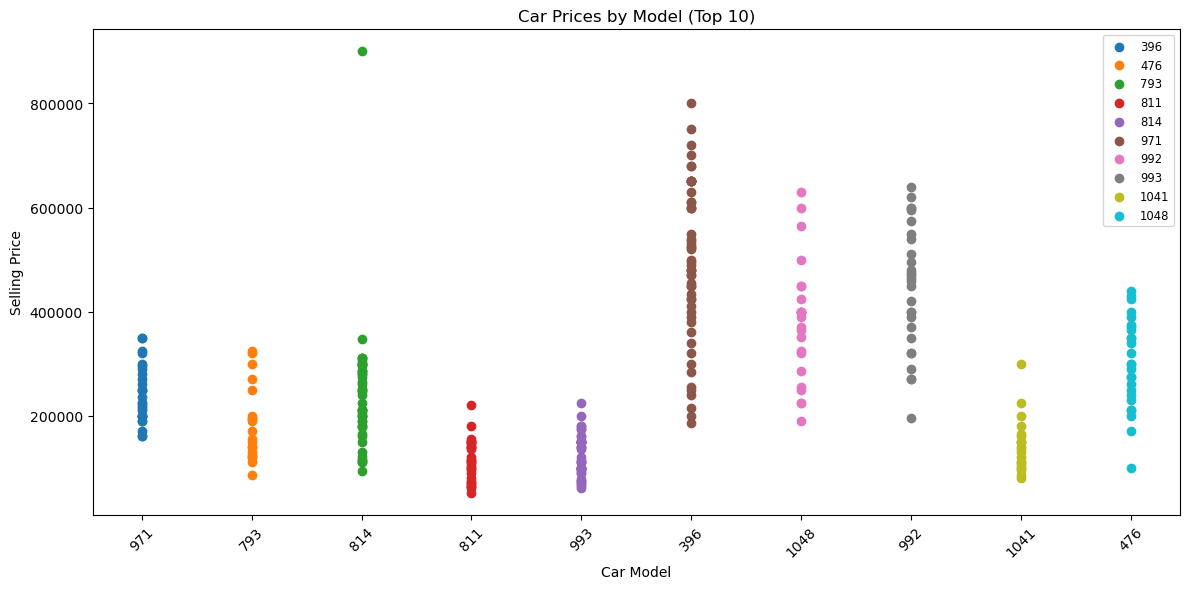

In [112]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Get top 10 car models
top_names = df['name'].value_counts().nlargest(10).index
df_top = df[df['name'].isin(top_names)]

# Plot data
for i, (name, group) in enumerate(df_top.groupby('name')):
    x = [i] * len(group)  # Give a numeric x-coordinate for scatter
    plt.scatter(x, group['selling_price'], label=name)

# Formatting
plt.title('Car Prices by Model (Top 10)')
plt.xlabel('Car Model')
plt.ylabel('Selling Price')
plt.xticks(ticks=range(len(top_names)), labels=top_names, rotation=45)
plt.legend(fontsize='small')
plt.tight_layout()
plt.show()


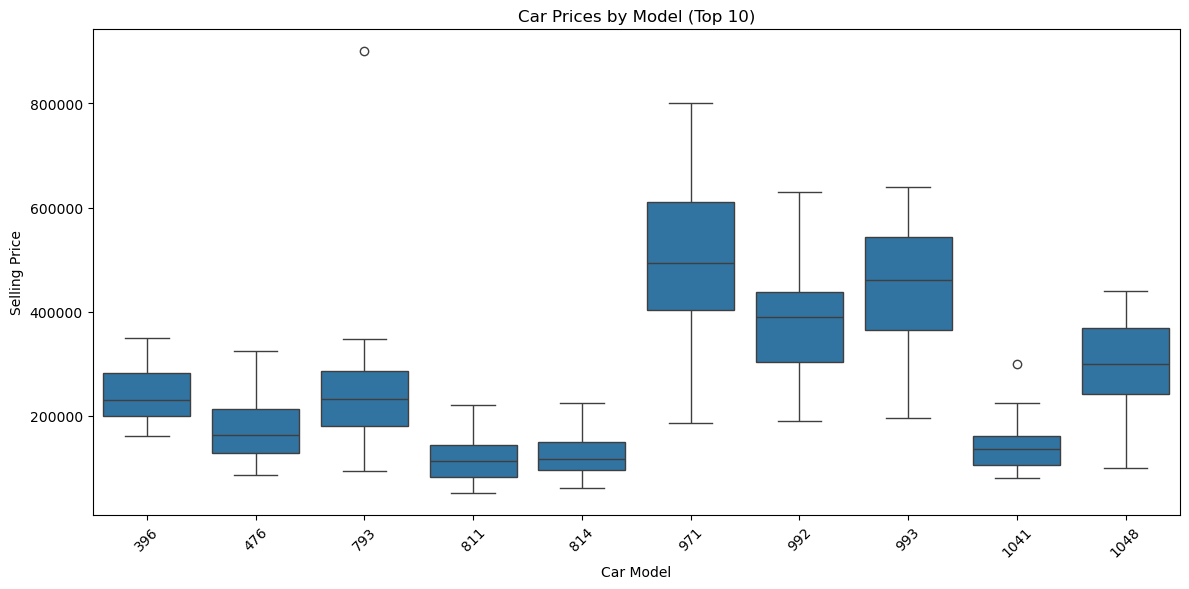

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top, x='name', y='selling_price')
plt.title('Car Prices by Model (Top 10)')
plt.xlabel('Car Model')
plt.ylabel('Selling Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


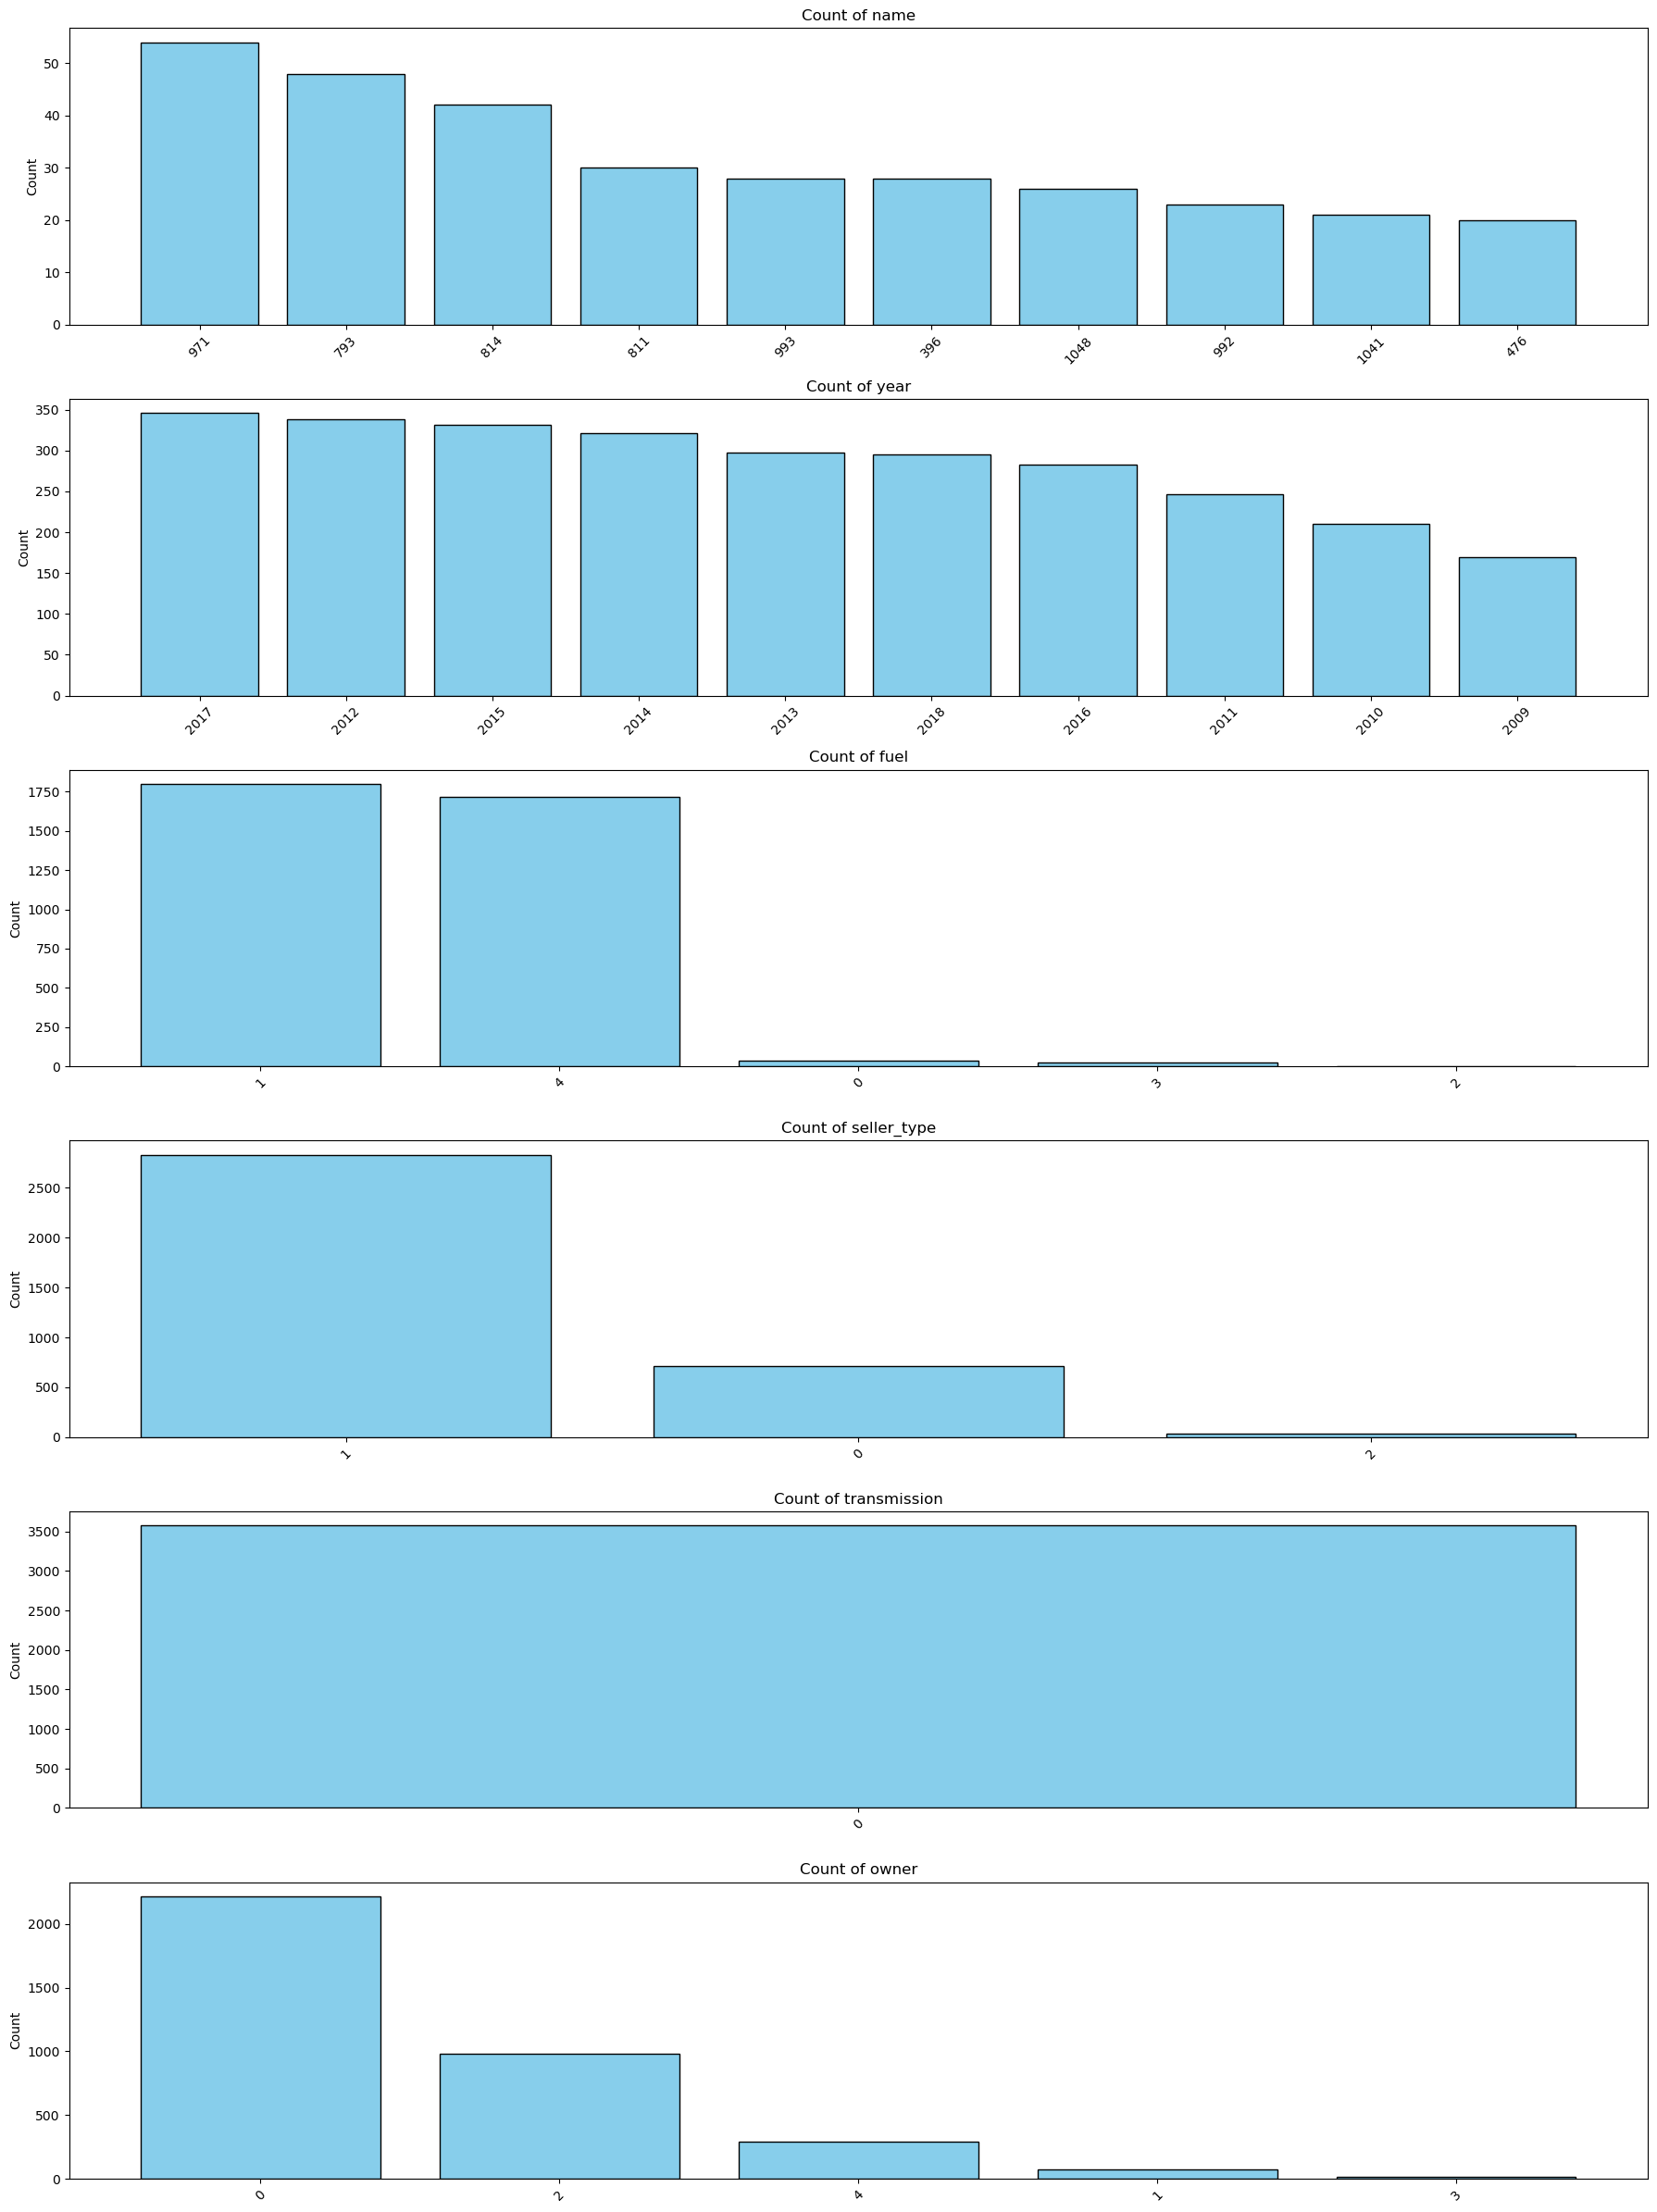

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your categorical columns
categorical_columns = ['name', 'year', 'fuel', 'seller_type', 'transmission', 'owner']

# Set up subplots
fig, axes = plt.subplots(nrows=len(categorical_columns), figsize=(18, 4 * len(categorical_columns)))

for i, column in enumerate(categorical_columns):
    # Get value counts for the column
    value_counts = df[column].value_counts()

    # For high-cardinality columns, take top 10
    if len(value_counts) > 20:
        value_counts = value_counts[:10]

    # Plot using standard bar chart
    axes[i].bar(value_counts.index.astype(str), value_counts.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Count of {column}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


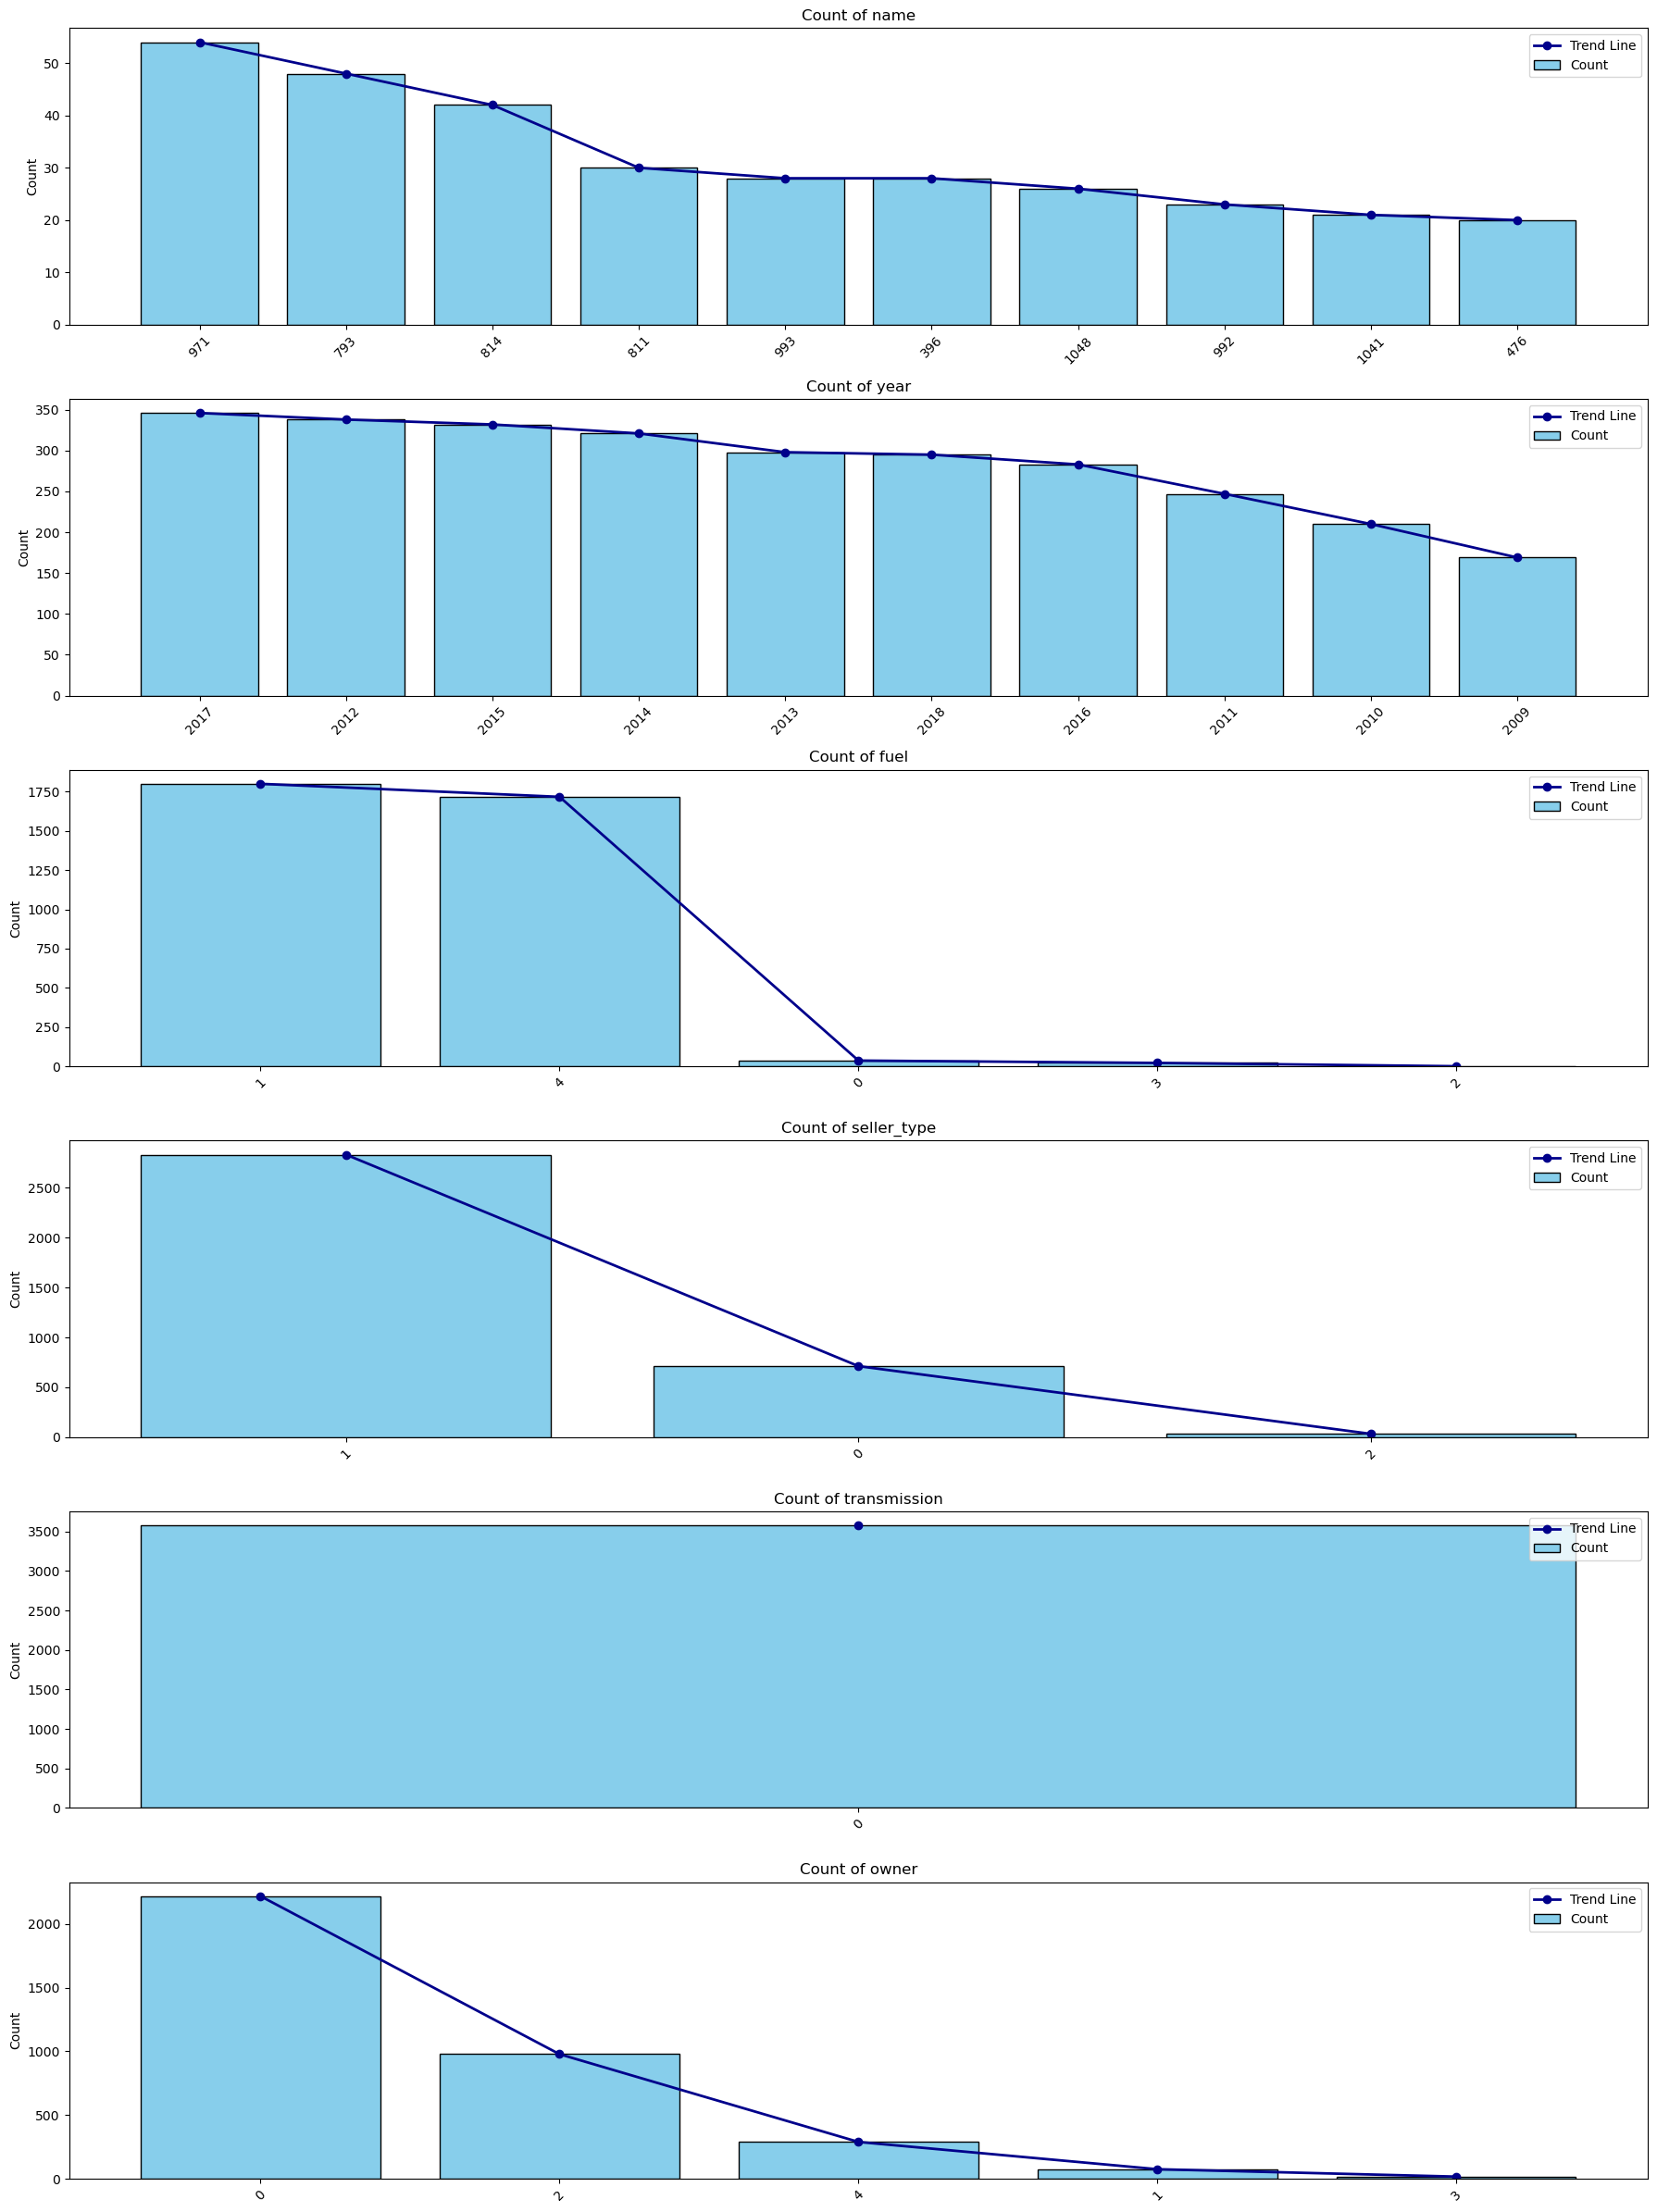

In [115]:
import matplotlib.pyplot as plt

# Your categorical columns
categorical_columns = ['name', 'year', 'fuel', 'seller_type', 'transmission', 'owner']

# Create subplots
fig, axes = plt.subplots(nrows=len(categorical_columns), figsize=(18, 4 * len(categorical_columns)))

for i, column in enumerate(categorical_columns):
    # Count frequencies
    value_counts = df[column].value_counts()

    # Limit to top 10 for high-cardinality columns
    if len(value_counts) > 20:
        value_counts = value_counts[:10]

    x = value_counts.index.astype(str)
    y = value_counts.values

    # Bar plot
    axes[i].bar(x, y, color='skyblue', edgecolor='black', label='Count')
    
    # Line plot
    axes[i].plot(x, y, color='darkblue', marker='o', linewidth=2, label='Trend Line')

    # Title and formatting
    axes[i].set_title(f'Count of {column}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend()

plt.tight_layout()
plt.show()


## feature engineering and feature selection

In [ ]:
X = df.drop(['selling_price'], axis=1) #dataframe
y = df['selling_price']
y.shape 
X
df

,name,year,selling_price,km_driven,fuel,seller_type,owner,transmission
0,775,2007,60000,70000,4,1,0,0
1,1041,2007,135000,50000,4,1,0,0
2,505,2012,600000,100000,1,1,0,0
3,118,2017,250000,46000,4,1,0,0
4,279,2014,450000,141000,1,1,2,0
...,...,...,...,...,...,...,...,...
4335,602,2014,409999,80000,1,1,2,0
4336,601,2014,409999,80000,1,1,2,0
4337,777,2009,110000,83000,4,1,2,0
4338,381,2016,865000,90000,1,1,0,0


In [ ]:
x=df.iloc[:,1:9].values 
scaler_min = MinMaxScaler() 
x_scaled = scaler_min.fit_transform(x) 
x_scaled.shape 
y.shape, x.shape

((3577,), (3577, 7))

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load data
df = pd.read_csv(r"C:\Users\rosha\CAR DETAILS FROM CAR DEKHO.csv")

# Clean 'km_driven'
df['km_driven'] = df['km_driven'].apply(
    lambda x: float(str(x).replace('miles', '')) * 1.60934 if 'miles' in str(x)
    else float(str(x).replace('km', '').replace(',', '').strip())
)

# Initialize label encoders
label_encoder_name = LabelEncoder()
label_encoder_fuel = LabelEncoder()
label_encoder_seller = LabelEncoder()
label_encoder_trans = LabelEncoder()
label_encoder_owner = LabelEncoder()

# Fit and transform
df['name'] = label_encoder_name.fit_transform(df['name'])
df['fuel'] = label_encoder_fuel.fit_transform(df['fuel'])
df['seller_type'] = label_encoder_seller.fit_transform(df['seller_type'])
df['transmission'] = label_encoder_trans.fit_transform(df['transmission'])
df['owner'] = label_encoder_owner.fit_transform(df['owner'])

# Select feature columns
feature_cols = ['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'name']
x = df[feature_cols].values

# Normalize
scaler_min = MinMaxScaler()
x_scaled = scaler_min.fit_transform(x)

print("x_scaled shape:", x_scaled.shape)


x_scaled shape: (4340, 7)


# model training

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming df is your DataFrame and 'selling_price' is the target
X = df.drop(columns=['selling_price'])
Y = df['selling_price']

# Split the data (80% train, 20% test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [ ]:
# check accuracy of each algorithm -
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import pandas as pd
import numpy as np

# Ideal R² score (for bias reference)
ideal_r2 = 0.95

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(),
    'SVM': SVR(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0)  # <-- XGBoost added
}

# Store results
results = []

for name, model in models.items():
    model.fit(X_train, Y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    train_r2 = r2_score(Y_train, pred_train)
    test_r2 = r2_score(Y_test, pred_test)
    train_mse = mean_squared_error(Y_train, pred_train)
    test_mse = mean_squared_error(Y_test, pred_test)

    bias = abs(ideal_r2 - train_r2)
    variance = abs(train_r2 - test_r2)

    # Determine status
    if bias < 0.05 and variance > 0.1:
        status = "Overfitting"
    elif bias > 0.1 and variance < 0.05:
        status = "Underfitting"
    else:
        status = "Good"

    results.append([
        name,
        round(train_mse, 2),
        round(test_mse, 2),
        round(train_r2, 3),
        round(test_r2, 3),
        round(bias, 3),
        round(variance, 3),
        status
    ])

# Final results table
df_results = pd.DataFrame(results, columns=[
    "Model", "Train_MSE", "Test_MSE", "Train_R2", "Test_R2", "Bias", "Variance", "Status"
])

print(df_results)


               Model     Train_MSE      Test_MSE  Train_R2  Test_R2   Bias  \
0  Linear Regression  1.841526e+11  1.843321e+11     0.461    0.396  0.489   
1                KNN  1.342041e+11  2.232430e+11     0.608    0.268  0.342   
2      Decision Tree  3.091511e+07  1.434829e+11     1.000    0.530  0.050   
3                SVM  3.667023e+11  3.245288e+11    -0.072   -0.063  1.022   
4      Random Forest  9.835152e+09  9.271299e+10     0.971    0.696  0.021   
5            XGBoost  3.153605e+09  8.024288e+10     0.991    0.737  0.041   

   Variance        Status  
0     0.065          Good  
1     0.339          Good  
2     0.470   Overfitting  
3     0.009  Underfitting  
4     0.275   Overfitting  
5     0.254   Overfitting  


# tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout 
import numpy as np

# Dummy data (replace with your real data)
x_train = np.random.rand(100, 10)
y_train = np.random.rand(100, 1)

model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='linear')
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# View the model summary
model.summary()

# Fit the model
model.fit(x_train, y_train, epochs=10, batch_size=16)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2858 - mae: 0.4497
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1634 - mae: 0.3228 
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1280 - mae: 0.2858 
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1421 - mae: 0.3046 
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1300 - mae: 0.2888 
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1466 - mae: 0.3171 
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1344 - mae: 0.3060 
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1334 - mae: 0.2966 
Epoch 9/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1061 - mae: 0.2736
Epoch 10/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1005 - mae: 0.2526 


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Input, Dense, Dropout # type: ignore

# Load and prepare data
X = df.iloc[:, 1:9].values          # Features
y = df.iloc[:, 0].values            # Target

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Build model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='linear')
])

# Compile model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])

# Train model
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Evaluate performance
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test R² Score: {r2:.3f}")

# Convert predictions to DataFrame
output_df = pd.DataFrame({
    'name': range(len(y_pred)),                    # Replace Id → name
    'selling_price': y_pred.flatten()              # Replace Price → selling_price
})

# Optional: round the price to 2 decimals
output_df['selling_price'] = output_df['selling_price'].round(2)

# Preview output
print(output_df.head())
print(output_df.tail())
print(output_df.shape)  # Should show (411, 2)

output_df.to_csv('predicted_prices.csv', index=False)

Epoch 1/150


# improved Architecture & Optimizer-

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Nadam

# Improved model
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128), BatchNormalization(), LeakyReLU(),
    Dense(64), BatchNormalization(), LeakyReLU(),
    Dense(32), Dropout(0.3), LeakyReLU(),
    Dense(1, activation='linear')
])

# Compile with Nadam optimizer
model.compile(optimizer=Nadam(), loss='mean_squared_error', metrics=['mse'])

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 733191.4375 - mse: 733191.4375 - val_loss: 699076.0000 - val_mse: 699076.0000
Epoch 2/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 666421.2500 - mse: 666421.2500 - val_loss: 642937.2500 - val_mse: 642937.2500
Epoch 3/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 571148.3125 - mse: 571148.3125 - val_loss: 489632.2188 - val_mse: 489632.2188
Epoch 4/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 386850.3750 - mse: 386850.3750 - val_loss: 279885.6250 - val_mse: 279885.6250
Epoch 5/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 239352.5156 - mse: 239352.5156 - val_loss: 172307.0625 - val_mse: 172307.0625
Epoch 6/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 179732.6562 - mse: 179732.6562 - val_loss: 150826.7344 - val_mse: 150826.7344
Epoch 7/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 169067.7344 - mse: 169067.7344 - val_loss: 152171.6719 - val_mse: 152171.6719
Epoch 8/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 1s

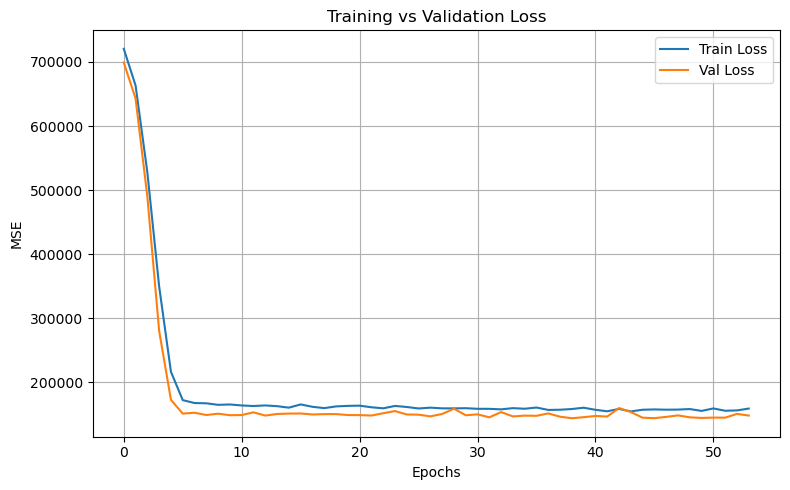

28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

📊Model Results:
Test Loss: 142876.45
Mean Squared Error: 142876.46
R² Score: 0.0850


In [ ]:
# Plot losses
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
test_loss, test_mse = model.evaluate(X_test, y_test, verbose=0)

print("\n📊Model Results:")
print(f"Test Loss: {test_loss:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.4f}")


In [ ]:
output_df = pd.DataFrame({
    'name': range(len(y_pred)),
    'selling_price': y_pred.flatten().round(2)
})
print(output_df.head())
print(output_df.shape)


   name  selling_price
0     0     889.890015
1     1     802.340027
2     2     758.330017
3     3     892.059998
4     4     787.039978
(868, 2)


# final

In [ ]:
model.save("car_price_model.keras")

In [ ]:
from tensorflow.keras.models import load_model
import numpy as np
import os

class Prediction:
    def __init__(self):
        self.model = load_model("car_price_model.keras") 

    def predict_price(self, form_data):
        values = [float(form_data[key]) for key in form_data]
        arr = np.array([values])
        result = self.model.predict(arr)[0][0]
        return round(result, 2)


## Additional Metrics (MAE + RMSE)

In [ ]:
from sklearn.metrics import mean_absolute_error
import math

mae = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mse)  # mse is already calculated earlier

print(f"📊 MAE (Mean Absolute Error): ₹{mae:.2f}")
print(f"📈 RMSE (Root Mean Squared Error): ₹{rmse:.2f}")
print(f"🎯 R² Score: {r2_score(y_test, y_pred):.4f}")


📊 MAE (Mean Absolute Error): ₹317.06
📈 RMSE (Root Mean Squared Error): ₹377.99
🎯 R² Score: 0.0850


## Ridge and Lasso hyperparameter model training

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.9001000000000000001)
ridge.fit(x_train, y_train)


Ridge(alpha=1.9001)

In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import Lasso

# Example splitting (if not already done)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

hyper = {"alpha": np.arange(0.0001, 2, 0.01)}
lasso_model = Lasso()

gscv = GridSearchCV(lasso_model, hyper, cv=5)
gscv.fit(X_train, y_train)

print("Best Alpha:", gscv.best_params_)
print("Best Score:", gscv.best_score_)


Best Alpha: {'alpha': 0.0001}
Best Score: 0.03401769306557012


In [ ]:
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Hyperparameter tuning
hyper = {"alpha": np.arange(0.0001, 2, 0.01)}
lasso_model = Lasso()
gscv = GridSearchCV(lasso_model, hyper, cv=5)
gscv.fit(x_train, y_train)

# Best model
lasso_best = gscv.best_estimator_

# Evaluation function
def car_model_evaluation(model, X, y):
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)
    
    print("Mean Squared Error =", mse)
    print("Mean Absolute Error =", mae)
    print("R2 Score =", r2)
    return "Success"

# Evaluate on train and test data
car_model_evaluation(lasso_best, x_train, y_train)
car_model_evaluation(lasso_best, x_test, y_test)


Mean Squared Error = 154740.64239279903
Mean Absolute Error = 332.97663784440977
R2 Score = 0.038615041477604306
Mean Squared Error = 148533.32782275145
Mean Absolute Error = 323.87705044766886
R2 Score = 0.04873894022585512


'Success'

In [ ]:
import os

# Create 'app' folder if it doesn't exist
os.makedirs('app', exist_ok=True)

# Now save model safely
import pickle

with open('app/Car_Pred_Model.pkl', 'wb') as f:
    pickle.dump(lasso_best, f)

print("✅ Model saved successfully!")


✅ Model saved successfully!


In [ ]:
import pandas as pd
import numpy as np
import os
import json
import pickle
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.preprocessing import LabelEncoder

# Step 1: Load the dataset
df = pd.read_csv("car_details.csv")

# Step 2: Encode 'name' using LabelEncoder
le_name = LabelEncoder()
df['name'] = le_name.fit_transform(df['name'])
name_mapping = {
    str(k): int(v) for k, v in zip(le_name.classes_, le_name.transform(le_name.classes_))
}

# Step 3: Define mappings for categorical columns
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 3, 'Electric': 4}
seller_mapping = {'Dealer': 0, 'Individual': 1, 'Trustmark Dealer': 2}
transmission_mapping = {'Manual': 0, 'Automatic': 1}
owner_mapping = {
    'First Owner': 0, 'Second Owner': 1, 'Third Owner': 2,
    'Fourth & Above Owner': 3, 'Test Drive Car': 4
}

# Step 4: Apply encodings
df['fuel'] = df['fuel'].map(fuel_mapping)
df['seller_type'] = df['seller_type'].map(seller_mapping)
df['transmission'] = df['transmission'].map(transmission_mapping)
df['owner'] = df['owner'].map(owner_mapping)

# Step 5: Define features and target
X = df.drop(columns=['selling_price'])  # includes 'name'
y = df['selling_price']

# Step 6: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 7: Lasso hyperparameter tuning
lasso = Lasso()
params = {"alpha": np.arange(0.0001, 2, 0.01)}
grid = GridSearchCV(lasso, params, cv=5)
grid.fit(X_train, y_train)

print("✅ Best alpha:", grid.best_params_)
print("✅ Best score:", grid.best_score_)

# Step 8: Train final model
final_model = Lasso(alpha=grid.best_params_['alpha'])
final_model.fit(X_train, y_train)

# Step 9: Save files to app/
os.makedirs('app', exist_ok=True)

# Save model
with open('app/Car_Pred_Model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save column names
columns = list(X.columns)  # ['name', 'year', 'km_driven', ...]
with open('app/Column.json', 'w') as f:
    json.dump(columns, f)

# Save all encodings
encoded_data = {
    'name': name_mapping,
    'fuel': {k: int(v) for k, v in fuel_mapping.items()},
    'seller_type': {k: int(v) for k, v in seller_mapping.items()},
    'transmission': {k: int(v) for k, v in transmission_mapping.items()},
    'owner': {k: int(v) for k, v in owner_mapping.items()}
}
with open('app/encoded_data.json', 'w') as f:
    json.dump(encoded_data, f)

print("✅ All done — model, columns, and encodings saved!")


✅ Best alpha: {'alpha': 1.9901}
✅ Best score: 0.4455179065767382
✅ All done — model, columns, and encodings saved!


In [ ]:
# Get the best model from GridSearchCV
lasso_best = gscv.best_estimator_

# Make sure your 'app' directory exists
import os
os.makedirs('app', exist_ok=True)

# Save your trained model
import pickle
with open('app/Car_Pred_Model.pkl', 'wb') as f:
    pickle.dump(lasso_best, f)

print("✅ Model saved successfully!")


✅ Model saved successfully!


In [ ]:
import json

# Assuming your final features are like this:
final_columns = ['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

# Save Column.json
with open("app/Column.json", "w") as f:
    json.dump(final_columns, f)


In [ ]:
import json
from sklearn.preprocessing import LabelEncoder

# Encode 'name' (car model)
le_name = LabelEncoder()
df['name'] = le_name.fit_transform(df['name'])

# Create mappings with plain Python types
name_map = {str(k): int(v) for k, v in zip(le_name.classes_, le_name.transform(le_name.classes_))}

fuel_map = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 3, 'Electric': 4}
seller_map = {'Dealer': 0, 'Individual': 1, 'Trustmark Dealer': 2}
trans_map = {'Manual': 0, 'Automatic': 1}
owner_map = {
    'First Owner': 0,
    'Second Owner': 1,
    'Third Owner': 2,
    'Fourth & Above Owner': 3,
    'Test Drive Car': 4
}

# Final encodings dictionary with type-safe integers
encodings = {
    "name": name_map,
    "fuel": {k: int(v) for k, v in fuel_map.items()},
    "seller_type": {k: int(v) for k, v in seller_map.items()},
    "transmission": {k: int(v) for k, v in trans_map.items()},
    "owner": {k: int(v) for k, v in owner_map.items()}
}

# Save encodings to JSON
with open("app/encoded_data.json", "w") as f:
    json.dump(encodings, f)

# Update feature columns
columns = ['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']
with open("app/Column.json", "w") as f:
    json.dump(columns, f)

print("✅ Encodings and columns saved successfully!")


✅ Encodings and columns saved successfully!


In [ ]:
# Import necessary libraries
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import pickle

# Step 1: Define parameter grid for alpha (or use your previous range)
param_grid = {'alpha': [0.01, 0.1, 1, 10]}

# Step 2: Create GridSearchCV object
grid = GridSearchCV(Lasso(), param_grid, cv=5)

# Step 3: Fit GridSearchCV on your training data
grid.fit(X_train, y_train)

# Step 4: Get best model from GridSearchCV
lasso_best = grid.best_estimator_

# OPTIONAL: print best alpha to verify
print("Best alpha:", grid.best_params_)

# Step 5: Save your trained model to a pickle file
with open("Car_Pred_Model.pkl", "wb") as f:
    pickle.dump(lasso_best, f)

print("✅ Model saved successfully!")


Best alpha: {'alpha': 10}
✅ Model saved successfully!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Lasso
import pickle
import os

# 1️⃣ Load Dataset
df = pd.read_csv("car_details.csv")
df = df.drop(columns=['name'])

# 2️⃣ Encoding
fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 3, 'Electric': 4}
seller_mapping = {'Dealer': 0, 'Individual': 1, 'Trustmark Dealer': 2}
transmission_mapping = {'Manual': 0, 'Automatic': 1}
owner_mapping = {
    'First Owner': 0, 'Second Owner': 1, 'Third Owner': 2, 
    'Fourth & Above Owner': 3, 'Test Drive Car': 4
}

df['fuel'] = df['fuel'].map(fuel_mapping)
df['seller_type'] = df['seller_type'].map(seller_mapping)
df['transmission'] = df['transmission'].map(transmission_mapping)
df['owner'] = df['owner'].map(owner_mapping)

# 3️⃣ Train model
X = df.drop(columns=['selling_price'])
y = df['selling_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

hyper = {"alpha": np.arange(0.0001, 2, 0.01)}
lasso_model = Lasso()
gscv = GridSearchCV(lasso_model, hyper, cv=5)
gscv.fit(X_train, y_train)

lasso_best = gscv.best_estimator_

# 4️⃣ Save model (✅ FIX)
os.makedirs('app', exist_ok=True)
with open('app/Car_Pred_Model.pkl', 'wb') as f:
    pickle.dump(lasso_best, f)

print("✅ Model trained and saved successfully!")


✅ Model trained and saved successfully!


In [ ]:
import os
import pickle

os.makedirs('app', exist_ok=True)

with open('app/Car_Pred_Model.pkl', 'wb') as f:
    pickle.dump(lasso_best, f)

print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
# Already prepared:
encodings = {
    'name': name_map,
    'fuel': {k: int(v) for k, v in fuel_map.items()},
    'seller_type': {k: int(v) for k, v in seller_map.items()},
    'transmission': {k: int(v) for k, v in trans_map.items()},
    'owner': {k: int(v) for k, v in owner_map.items()}
}

columns = ['name', 'year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']

# ✅ Paste this below:
import os

# Make sure folder exists
os.makedirs("app", exist_ok=True)

try:
    with open("app/encoded_data.json", "w") as f:
        json.dump(encodings, f)
    print("✅ encoded_data.json saved")
except Exception as e:
    print("❌ Failed to save encoded_data.json:", e)

try:
    with open("app/Column.json", "w") as f:
        json.dump(columns, f)
    print("✅ Column.json saved")
except Exception as e:
    print("❌ Failed to save Column.json:", e)


✅ encoded_data.json saved
✅ Column.json saved


## TESTING

In [ ]:
# 📦 Imports
import pandas as pd
import numpy as np
import pickle
import json

# ✅ Load model and scaler
with open("app/Car_Pred_Model.pkl", "rb") as f:
    model = pickle.load(f)

with open("app/scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# ✅ Load encodings (optional for lookup)
with open("app/encoded_data.json", "r") as f:
    encodings = json.load(f)

with open("app/Column.json", "r") as f:
    columns = json.load(f)

print("🧾 Expected columns:", columns)

# ✅ Test input (simulate form data)
# Example: [year, km_driven, fuel, seller_type, transmission, owner]
# You can edit the values below
test_input = [2007, 70000, 0, 1, 0, 0]  # 👈 matches dropdowns: Petrol, Individual, Manual, First Owner

# ✅ Convert to numpy array and scale
test_array = np.array(test_input).reshape(1, -1)
scaled_input = scaler.transform(test_array)

# ✅ Predict the price
predicted_price = model.predict(scaled_input)[0]
predicted_price = round(max(0, predicted_price), 2)  # 👈 Clamp negative to 0

print("✅ Predicted Price: ₹", predicted_price)


FileNotFoundError: [Errno 2] No such file or directory: 'app/Car_Pred_Model.pkl'

In [4]:
# ==========================================
# FINAL TRAINING PIPELINE (REPLACE TRAINING)
# ==========================================

import pandas as pd
import numpy as np
import pickle
import json
import os

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import (
    RandomForestRegressor
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv(
    "car_details.csv"
)

# ==========================================
# FEATURE ENGINEERING
# ==========================================

current_year = 2026

df["car_age"] = (
    current_year - df["year"]
)

df["km_per_year"] = (
    df["km_driven"] /
    np.maximum(
        df["car_age"],
        1
    )
)

# ==========================================
# ENCODING
# ==========================================

fuel_mapping = {
    'Petrol':0,
    'Diesel':1,
    'CNG':2,
    'LPG':3,
    'Electric':4
}

seller_mapping = {
    'Dealer':0,
    'Individual':1,
    'Trustmark Dealer':2
}

transmission_mapping = {
    'Manual':0,
    'Automatic':1
}

owner_mapping = {
    'First Owner':0,
    'Second Owner':1,
    'Third Owner':2,
    'Fourth & Above Owner':3,
    'Test Drive Car':4
}

df['fuel'] = df[
    'fuel'
].map(
    fuel_mapping
)

df['seller_type'] = df[
    'seller_type'
].map(
    seller_mapping
)

df['transmission'] = df[
    'transmission'
].map(
    transmission_mapping
)

df['owner'] = df[
    'owner'
].map(
    owner_mapping
)

# ==========================================
# FEATURES
# ==========================================

X = df[
[
'year',
'km_driven',
'fuel',
'seller_type',
'transmission',
'owner',
'car_age',
'km_per_year'
]
]

y = df[
    'selling_price'
]

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)

# ==========================================
# RANDOM FOREST
# ==========================================

model = RandomForestRegressor(
    random_state=42
)

hyper = {

    "n_estimators":[
        100,
        200
    ],

    "max_depth":[
        10,
        20,
        None
    ],

    "min_samples_split":[
        2,
        5
    ]
}

grid = GridSearchCV(
    model,
    hyper,
    cv=5,
    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

best_model = (
    grid.best_estimator_
)

# ==========================================
# EVALUATE
# ==========================================

pred = best_model.predict(
    X_test
)

r2 = r2_score(
    y_test,
    pred
)

mae = mean_absolute_error(
    y_test,
    pred
)

print(
    "R² Score:",
    r2
)

print(
    "MAE:",
    mae
)

print(
    "Best Parameters:"
)

print(
    grid.best_params_
)

# ==========================================
# SAVE ARTIFACTS
# ==========================================

os.makedirs(
    "app",
    exist_ok=True
)

with open(
    'app/Car_Pred_Model.pkl',
    'wb'
) as f:

    pickle.dump(
        best_model,
        f
    )

columns = list(
    X.columns
)

with open(
    'app/Column.json',
    'w'
) as f:

    json.dump(
        columns,
        f
    )

encodings = {

'fuel':
fuel_mapping,

'seller_type':
seller_mapping,

'transmission':
transmission_mapping,

'owner':
owner_mapping

}

with open(
    'app/encoded_data.json',
    'w'
) as f:

    json.dump(
        encodings,
        f
    )

print(
    "✅ Model + files saved successfully"
)

R² Score: 0.49094428215662855
MAE: 169649.27303736412
Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
✅ Model + files saved successfully


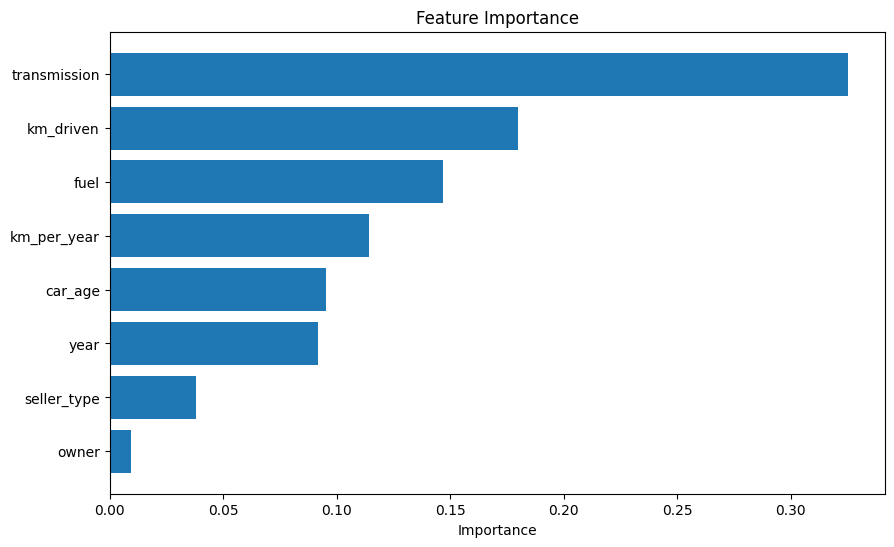

Saved


<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

importance = best_model.feature_importances_

feature_df = pd.DataFrame({

    "Feature": X.columns,
    "Importance": importance

})

feature_df = feature_df.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(
    figsize=(10,6)
)

plt.barh(

    feature_df["Feature"],
    feature_df["Importance"]

)

plt.xlabel(
    "Importance"
)

plt.title(
    "Feature Importance"
)

plt.show()

plt.savefig(
    "feature_importance.png",
    bbox_inches="tight"
)

print(
    "Saved"
)

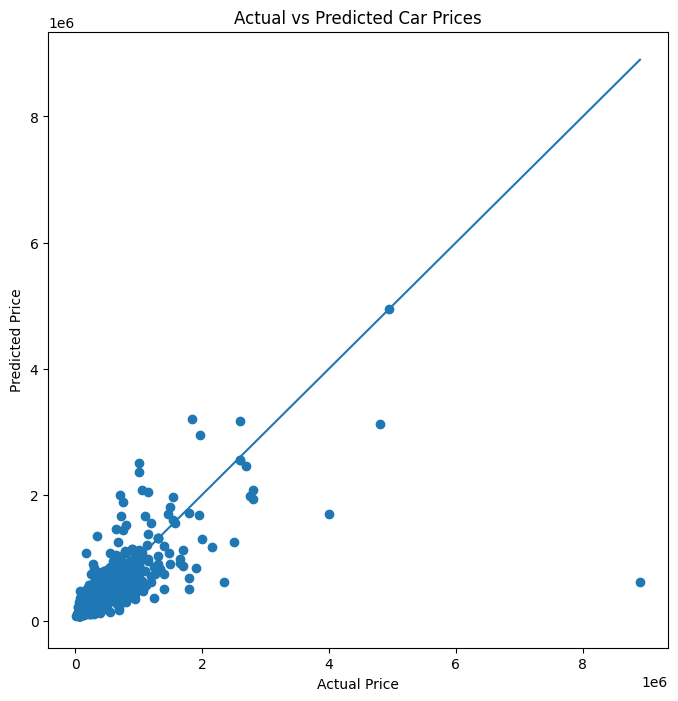

Saved


<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(8,8)
)

plt.scatter(
    y_test,
    pred
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted Car Prices"
)

min_val = min(
    y_test.min(),
    pred.min()
)

max_val = max(
    y_test.max(),
    pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val]
)

plt.show()

plt.savefig(
    "prediction_vs_actual.png",
    bbox_inches="tight"
)

print(
    "Saved"
)